# Smartphone Addiction Prediction — Kaggle Playground Series 2026

## Project Overview

## Carlos Alberto Escalante Gutiérrez

This project was developed as part of the 2026 Kaggle Playground Series, with the goal of building a machine learning model capable of predicting whether an individual shows signs of smartphone addiction based on behavioral and lifestyle data.

The problem was formulated as a binary classification task, where the target variable `addicted_label` indicates whether a person belongs to the addicted class. Model performance was evaluated using the Area Under the ROC Curve (ROC-AUC), which measures how effectively the model ranks positive cases above negative ones across different classification thresholds.

Rather than relying on a single model, this project evolved through multiple stages including exploratory data analysis, missing-value analysis, feature engineering, gradient boosting models, cross-validation, frequency encoding, hyperparameter experimentation, and model ensembling.

The main objective was not only to maximize leaderboard performance, but also to build a reproducible experimentation workflow and understand which modeling decisions produced measurable improvements.

## 1. Environment and Configuration

The project uses Python and the standard data science ecosystem for data manipulation, visualization, model validation, and machine learning.

Throughout the project, the same cross-validation strategy was preserved whenever possible so that improvements between experiments could be compared under consistent conditions.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

### Project Structure

The repository separates raw competition data from generated outputs. This makes the workflow easier to reproduce and prevents model predictions and intermediate files from being mixed with the original datasets.

In [5]:
BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Initial Dataset Exploration

The competition provided two tabular datasets: a labeled training set used to develop and validate the models, and an unlabeled test set used to generate the final Kaggle predictions.

The training dataset contained 691,369 observations and 14 columns, while the test dataset contained 296,302 observations and 13 columns. The additional column in the training set corresponds to the prediction target, `addicted_label`.

In [6]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print(f"Training set shape: {train.shape}")
print(f"Test set shape:     {test.shape}")

Training set shape: (691369, 14)
Test set shape:     (296302, 13)


### Available Features

The dataset combines demographic information with smartphone usage, digital interaction, sleep, stress, and academic/work-related variables.

The original features included:

- Age
- Daily screen time
- Social media usage
- Gaming time
- Work or study time
- Sleep duration
- Notifications received per day
- App opens per day
- Weekend screen time
- Gender
- Stress level
- Academic or work impact

These variables provided multiple perspectives on digital behavior, making it possible to construct additional behavioral ratios and interaction features later in the project.

In [7]:
print("Training columns:\n")

for column in train.columns:
    print(f"- {column}")

Training columns:

- id
- age
- daily_screen_time_hours
- social_media_hours
- gaming_hours
- work_study_hours
- sleep_hours
- notifications_per_day
- app_opens_per_day
- weekend_screen_time
- gender
- stress_level
- academic_work_impact
- addicted_label


In [8]:
train.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


### Data Types and Completeness

The dataset contains both numerical and categorical variables. An initial inspection also revealed that missing values were present across a significant portion of the features.

Because tree-based models such as LightGBM and CatBoost can handle missing values natively, missingness was treated not only as a preprocessing problem but also as a potentially informative characteristic of the dataset.

In [9]:
dataset_summary = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing_values": train.isna().sum(),
    "missing_percentage": (
        train.isna().mean() * 100
    ).round(2),
    "unique_values": train.nunique()
})

dataset_summary

,dtype,missing_values,missing_percentage,unique_values
id,int64,0,0.00,691369
age,float64,28929,4.18,18
daily_screen_time_hours,float64,95854,13.86,1389
social_media_hours,float64,133995,19.38,721
gaming_hours,float64,126821,18.34,401
work_study_hours,float64,51518,7.45,600
sleep_hours,float64,44480,6.43,451
notifications_per_day,float64,67584,9.78,231
app_opens_per_day,float64,80710,11.67,166
weekend_screen_time,float64,112063,16.21,1437


### Missing-Value Analysis

Missing data was one of the most noticeable characteristics of the dataset. Several important behavioral variables contained a substantial proportion of missing observations.

Instead of immediately imputing every missing value, the modeling strategy preserved the original missing values and later experimented with explicit missing-value indicators. This allowed the models to determine whether the absence of information itself contained predictive signal.

In [10]:
missing_summary = (
    train
    .drop(columns=["addicted_label"])
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_values")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_values"]
    / len(train)
    * 100
)

missing_summary

,missing_values,missing_percentage
social_media_hours,133995,19.381112
gaming_hours,126821,18.343461
weekend_screen_time,112063,16.208855
daily_screen_time_hours,95854,13.864376
app_opens_per_day,80710,11.673940
notifications_per_day,67584,9.775388
stress_level,55148,7.976638
work_study_hours,51518,7.451592
sleep_hours,44480,6.433612
academic_work_impact,44224,6.396584


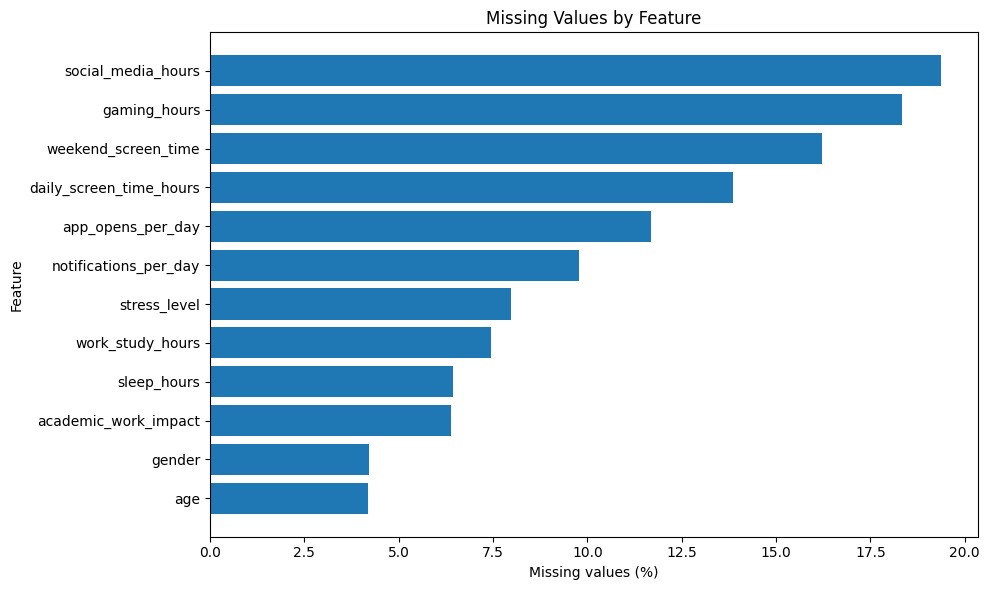

In [11]:
missing_plot = (
    missing_summary[
        missing_summary["missing_values"] > 0
    ]
    .sort_values("missing_percentage")
)

plt.figure(figsize=(10, 6))

plt.barh(
    missing_plot.index,
    missing_plot["missing_percentage"]
)

plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.title("Missing Values by Feature")

plt.tight_layout()
plt.show()

### Target Distribution

The target variable is moderately imbalanced. Approximately 71% of the training observations belong to the positive class.

Because the competition metric was ROC-AUC rather than accuracy, the modeling objective focused on correctly ranking observations by their probability of smartphone addiction rather than selecting a fixed classification threshold.

In [12]:
TARGET = "addicted_label"

target_distribution = (
    train[TARGET]
    .value_counts(normalize=True)
    .sort_index()
)

print(target_distribution)

addicted_label
0    0.290576
1    0.709424
Name: proportion, dtype: float64


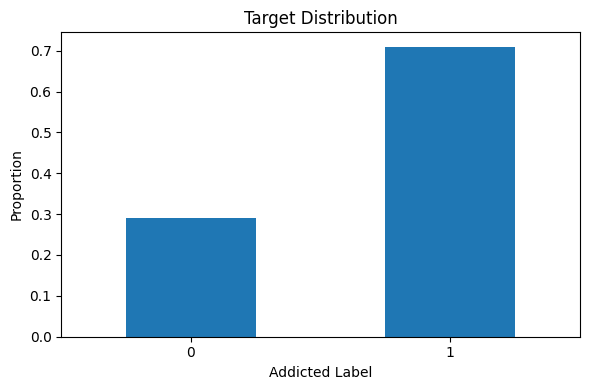

In [13]:
plt.figure(figsize=(6, 4))

target_distribution.plot(
    kind="bar"
)

plt.xlabel("Addicted Label")
plt.ylabel("Proportion")
plt.title("Target Distribution")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Feature Types

The initial dataset contained nine numerical predictors and three categorical predictors.

This combination made gradient-boosted decision trees particularly attractive for the problem, since they can capture non-linear relationships, feature interactions, missing-value patterns, and complex behavioral thresholds without requiring extensive transformations.

In [14]:
feature_columns = [
    column
    for column in train.columns
    if column not in ["id", TARGET]
]

categorical_features = (
    train[feature_columns]
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

numerical_features = [
    column
    for column in feature_columns
    if column not in categorical_features
]

print(
    f"Numerical features:   {len(numerical_features)}"
)

print(
    f"Categorical features: {len(categorical_features)}"
)

print("\nCategorical features:")
print(categorical_features)

Numerical features:   9
Categorical features: 3

Categorical features:
['gender', 'stress_level', 'academic_work_impact']


## 3. Baseline Modeling

Before introducing feature engineering or model ensembling, a baseline model was established using only the original features provided by the competition.

CatBoost was selected as the initial model because it is particularly well suited for tabular datasets containing a mixture of numerical and categorical variables. It can also handle missing numerical values natively and process categorical features without requiring one-hot encoding.

To obtain a reliable estimate of model performance, a 5-fold Stratified Cross-Validation strategy was used. The same fold structure was preserved throughout later experiments whenever possible, allowing improvements between different modeling approaches to be compared under consistent validation conditions.

The baseline therefore represents the performance that could be achieved before adding any domain-inspired behavioral features or advanced modeling strategies.

### Cross-Validation Strategy

Because the target distribution is not perfectly balanced, `StratifiedKFold` was used to preserve approximately the same class distribution across every validation fold.

Five folds provided a compromise between robust validation and computational cost.

In [15]:


ID_COL = "id"
TARGET = "addicted_label"

RANDOM_STATE = 42
N_SPLITS = 5

### Baseline Feature Set

The baseline intentionally uses only the 12 original predictor variables. The `id` column is excluded because it represents an observation identifier rather than a behavioral characteristic.

At this stage, no engineered ratios, interaction variables, frequency encodings, or explicit missing-value indicators are included.

In [16]:
X = train.drop(
    columns=[
        ID_COL,
        TARGET
    ]
).copy()

y = train[TARGET].copy()


categorical_features = (
    X
    .select_dtypes(
        include=[
            "object",
            "category"
        ]
    )
    .columns
    .tolist()
)


for column in categorical_features:

    X[column] = (
        X[column]
        .fillna("MISSING")
        .astype(str)
    )


print(
    f"Training observations: {len(X):,}"
)

print(
    f"Baseline features: {X.shape[1]}"
)

print(
    f"Categorical features: {len(categorical_features)}"
)

print(
    categorical_features
)

Training observations: 691,369
Baseline features: 12
Categorical features: 3
['gender', 'stress_level', 'academic_work_impact']


In [17]:
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


oof_predictions = np.zeros(
    len(X)
)


fold_scores = []


for fold, (
    train_index,
    valid_index
) in enumerate(
    skf.split(X, y),
    start=1
):

    print(
        f"\nTraining Fold {fold}/{N_SPLITS}"
    )


    X_train = X.iloc[
        train_index
    ]

    X_valid = X.iloc[
        valid_index
    ]


    y_train = y.iloc[
        train_index
    ]

    y_valid = y.iloc[
        valid_index
    ]


    model = CatBoostClassifier(

        iterations=3000,

        learning_rate=0.03,

        depth=7,

        loss_function="Logloss",

        eval_metric="AUC",

        random_seed=
            RANDOM_STATE + fold,

        verbose=500,

        allow_writing_files=False
    )


    model.fit(

        X_train,
        y_train,

        cat_features=
            categorical_features,

        eval_set=(
            X_valid,
            y_valid
        ),

        use_best_model=True
    )


    validation_predictions = (
        model
        .predict_proba(
            X_valid
        )[:, 1]
    )


    oof_predictions[
        valid_index
    ] = validation_predictions


    fold_auc = roc_auc_score(
        y_valid,
        validation_predictions
    )


    fold_scores.append(
        fold_auc
    )


    print(
        f"Fold {fold} ROC-AUC: "
        f"{fold_auc:.6f}"
    )


Training Fold 1/5
0:	test: 0.9080469	best: 0.9080469 (0)	total: 302ms	remaining: 15m 6s
500:	test: 0.9472985	best: 0.9472985 (500)	total: 1m 4s	remaining: 5m 20s
1000:	test: 0.9541949	best: 0.9541949 (1000)	total: 2m 13s	remaining: 4m 26s
1500:	test: 0.9572551	best: 0.9572551 (1500)	total: 3m 21s	remaining: 3m 21s
2000:	test: 0.9590278	best: 0.9590278 (2000)	total: 4m 29s	remaining: 2m 14s
2500:	test: 0.9602311	best: 0.9602311 (2500)	total: 5m 37s	remaining: 1m 7s
2999:	test: 0.9610365	best: 0.9610368 (2998)	total: 6m 46s	remaining: 0us

bestTest = 0.9610367974
bestIteration = 2998

Shrink model to first 2999 iterations.
Fold 1 ROC-AUC: 0.961037

Training Fold 2/5
0:	test: 0.9103123	best: 0.9103123 (0)	total: 128ms	remaining: 6m 23s
500:	test: 0.9478682	best: 0.9478682 (500)	total: 1m 9s	remaining: 5m 45s
1000:	test: 0.9548947	best: 0.9548947 (1000)	total: 2m 22s	remaining: 4m 43s
1500:	test: 0.9580036	best: 0.9580036 (1500)	total: 4m 15s	remaining: 4m 14s
2000:	test: 0.9597340	best: 

In [18]:
baseline_auc = roc_auc_score(
    y,
    oof_predictions
)


print("\nBaseline Results")
print("-" * 40)

for fold, score in enumerate(
    fold_scores,
    start=1
):

    print(
        f"Fold {fold}: "
        f"{score:.6f}"
    )


print("-" * 40)

print(
    f"Mean Fold AUC: "
    f"{np.mean(fold_scores):.6f}"
)

print(
    f"Overall OOF AUC: "
    f"{baseline_auc:.6f}"
)


Baseline Results
----------------------------------------
Fold 1: 0.961037
Fold 2: 0.961636
Fold 3: 0.962032
Fold 4: 0.962671
Fold 5: 0.961707
----------------------------------------
Mean Fold AUC: 0.961817
Overall OOF AUC: 0.961816


### Baseline Result

The initial CatBoost model produced an out-of-fold ROC-AUC of approximately 0.9618 using only the original competition features.

This established a strong baseline and confirmed that the original behavioral variables already contained substantial predictive information.

However, the result also provided an opportunity for further improvement. The next stage of the project focused on extracting additional behavioral information from the existing variables through feature engineering rather than immediately increasing model complexity.

## 4. Behavioral Feature Engineering
The original dataset already contained strong predictive information, but several variables described related aspects of smartphone behavior independently.

Feature engineering was used to transform these raw measurements into more interpretable behavioral indicators. Instead of simply increasing model complexity, the goal was to provide the models with additional representations of usage intensity, activity composition, sleep balance, weekend behavior, and missing-data patterns.

The first feature-engineering stage expanded the original 12 predictors into 38 features.

### Missing-Value Indicators

Missing values were preserved because gradient-boosting models can handle them natively. However, an additional binary indicator was created for each original feature to explicitly represent whether the observation was missing.

This allowed the models to distinguish between the actual value of a feature and the fact that the information itself was unavailable.

In [19]:
def add_missing_features(df):
    df = df.copy()

    original_columns = df.columns.tolist()

    for column in original_columns:
        df[f"{column}_missing"] = (
            df[column]
            .isna()
            .astype(np.uint8)
        )

    df["missing_count"] = (
        df[original_columns]
        .isna()
        .sum(axis=1)
    )

    return df

### Digital Usage Intensity

Raw values such as notifications or app opens provide useful information, but they do not account for how much time a person actually spends using their device.

To capture usage intensity, interaction counts were normalized by screen time and by the number of app opens.

In [20]:
EPS = 1e-6 #A small numerical constant (`EPS`) was added to ratio denominators to avoid division-by-zero errors.


def add_usage_intensity_features(df):
    df = df.copy()

    df["notifications_per_screen_hour"] = (
        df["notifications_per_day"]
        /
        (df["daily_screen_time_hours"] + EPS)
    )

    df["app_opens_per_screen_hour"] = (
        df["app_opens_per_day"]
        /
        (df["daily_screen_time_hours"] + EPS)
    )

    df["notifications_per_app_open"] = (
        df["notifications_per_day"]
        /
        (df["app_opens_per_day"] + EPS)
    )

    return df

### Weekend Behavior

Weekend smartphone usage can provide additional context about an individual's digital habits.

Two features were created to measure how weekend screen time differs from typical daily usage: an absolute difference and a relative ratio.

In [21]:
def add_weekend_features(df):
    df = df.copy()

    df["weekend_screen_difference"] = (
        df["weekend_screen_time"]
        -
        df["daily_screen_time_hours"]
    )

    df["weekend_screen_ratio"] = (
        df["weekend_screen_time"]
        /
        (df["daily_screen_time_hours"] + EPS)
    )

    return df

### Activity Composition

Total screen time alone does not explain how that time is distributed.

Social media, gaming, and work/study usage were combined to estimate the amount of known digital activity. The difference between total screen time and these reported activities was also calculated as an approximate measure of unaccounted screen usage.

In [22]:
def add_activity_features(df):
    df = df.copy()

    df["known_activity_hours"] = (
        df["social_media_hours"]
        +
        df["gaming_hours"]
        +
        df["work_study_hours"]
    )

    df["unaccounted_screen_time"] = (
        df["daily_screen_time_hours"]
        -
        df["known_activity_hours"]
    )

    return df

Rather than considering each activity only in absolute hours, activity-share features were also created to describe what proportion of total screen time was associated with social media, gaming, or work/study activities.

In [23]:
def add_activity_share_features(df):
    df = df.copy()

    df["social_media_share"] = (
        df["social_media_hours"]
        /
        (df["daily_screen_time_hours"] + EPS)
    )

    df["gaming_share"] = (
        df["gaming_hours"]
        /
        (df["daily_screen_time_hours"] + EPS)
    )

    df["work_study_share"] = (
        df["work_study_hours"]
        /
        (df["daily_screen_time_hours"] + EPS)
    )

    return df

### Screen Time and Sleep Balance

High screen time may become more meaningful when compared with the amount of sleep an individual receives.

To capture this relationship, screen-time-to-sleep ratios were created for both regular daily usage and weekend usage.

In [24]:
def add_sleep_features(df):
    df = df.copy()

    df["screen_sleep_ratio"] = (
        df["daily_screen_time_hours"]
        /
        (df["sleep_hours"] + EPS)
    )

    df["weekend_screen_sleep_ratio"] = (
        df["weekend_screen_time"]
        /
        (df["sleep_hours"] + EPS)
    )

    return df

### Overall Digital Interaction

Notifications and app openings represent two different forms of interaction with a smartphone.

A combined engagement feature was therefore introduced as a simple measure of total daily digital interactions.

In [25]:
def add_engagement_features(df):
    df = df.copy()

    df["digital_interactions"] = (
        df["notifications_per_day"]
        +
        df["app_opens_per_day"]
    )

    return df

### Complete Feature-Engineering Pipeline

The transformations above were combined into a single reproducible function so that exactly the same feature engineering could later be applied to both the training and test datasets.

In [26]:
def engineer_features(df):
    df = df.copy()

    # Missing-value information
    df = add_missing_features(df)

    # Behavioral intensity
    df = add_usage_intensity_features(df)

    # Weekend behavior
    df = add_weekend_features(df)

    # Activity composition
    df = add_activity_features(df)
    df = add_activity_share_features(df)

    # Screen and sleep balance
    df = add_sleep_features(df)

    # Overall digital engagement
    df = add_engagement_features(df)

    return df

In [27]:
X_original = train.drop(
    columns=[
        ID_COL,
        TARGET
    ]
).copy()

X_test_original = test.drop(
    columns=[
        ID_COL
    ]
).copy()

In [28]:
X_engineered = engineer_features(
    X_original
)

X_test_engineered = engineer_features(
    X_test_original
)


print(
    f"Original feature count:   "
    f"{X_original.shape[1]}"
)

print(
    f"Engineered feature count: "
    f"{X_engineered.shape[1]}"
)

Original feature count:   12
Engineered feature count: 38


In [29]:
engineered_only_features = [
    column
    for column in X_engineered.columns
    if column not in X_original.columns
]


print(
    f"New engineered features: "
    f"{len(engineered_only_features)}\n"
)


for feature in engineered_only_features:
    print(f"- {feature}")

New engineered features: 26

- age_missing
- daily_screen_time_hours_missing
- social_media_hours_missing
- gaming_hours_missing
- work_study_hours_missing
- sleep_hours_missing
- notifications_per_day_missing
- app_opens_per_day_missing
- weekend_screen_time_missing
- gender_missing
- stress_level_missing
- academic_work_impact_missing
- missing_count
- notifications_per_screen_hour
- app_opens_per_screen_hour
- notifications_per_app_open
- weekend_screen_difference
- weekend_screen_ratio
- known_activity_hours
- unaccounted_screen_time
- social_media_share
- gaming_share
- work_study_share
- screen_sleep_ratio
- weekend_screen_sleep_ratio
- digital_interactions


In [30]:
feature_engineering_summary = pd.DataFrame({
    "Feature Group": [
        "Missing Information",
        "Usage Intensity",
        "Weekend Behavior",
        "Activity Composition",
        "Activity Shares",
        "Screen / Sleep Balance",
        "Digital Engagement"
    ],

    "Examples": [
        "*_missing, missing_count",
        "notifications_per_screen_hour",
        "weekend_screen_ratio",
        "known_activity_hours",
        "social_media_share",
        "screen_sleep_ratio",
        "digital_interactions"
    ],

    "Purpose": [
        "Represent missing-data patterns",
        "Measure interaction intensity",
        "Compare weekday and weekend behavior",
        "Estimate how screen time is distributed",
        "Normalize activities by total screen time",
        "Relate device usage to sleeping habits",
        "Aggregate daily smartphone interactions"
    ]
})


feature_engineering_summary

,Feature Group,Examples,Purpose
0,Missing Information,"*_missing, missing_count",Represent missing-data patterns
1,Usage Intensity,notifications_per_screen_hour,Measure interaction intensity
2,Weekend Behavior,weekend_screen_ratio,Compare weekday and weekend behavior
3,Activity Composition,known_activity_hours,Estimate how screen time is distributed
4,Activity Shares,social_media_share,Normalize activities by total screen time
5,Screen / Sleep Balance,screen_sleep_ratio,Relate device usage to sleeping habits
6,Digital Engagement,digital_interactions,Aggregate daily smartphone interactions


### Feature-Engineering Outcome

The feature-engineering process increased the dataset from 12 original predictors to 38 features.

The objective was not simply to increase dimensionality. Each engineered variable attempted to represent a behavioral relationship that was not directly available in the raw dataset, such as usage intensity, activity composition, weekend behavior, or the balance between screen time and sleep.

These engineered features were then evaluated under the same cross-validation framework used by the baseline model to determine whether they provided genuine predictive value.

## 5. Evaluating Feature Engineering

To determine whether the engineered behavioral variables contained useful predictive information, CatBoost was trained again using the expanded feature set.

The validation strategy and general model configuration were kept consistent with the baseline experiment. This made it possible to attribute changes in ROC-AUC primarily to the additional features rather than to a different validation procedure.

This experiment increased the number of predictors from 12 to 38.

In [31]:
X_featured = X_engineered.copy()

categorical_features_featured = (
    X_featured
    .select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

for column in categorical_features_featured:

    X_featured[column] = (
        X_featured[column]
        .fillna("MISSING")
        .astype(str)
    )


print(
    f"Features used: "
    f"{X_featured.shape[1]}"
)

print(
    f"Categorical features: "
    f"{len(categorical_features_featured)}"
)

Features used: 38
Categorical features: 3


### CatBoost with Engineered Features

The same five-fold stratified cross-validation procedure was used to evaluate the expanded feature set.

Out-of-fold predictions were stored so that performance could be measured across the entire training dataset rather than relying on a single validation split.

In [32]:
feature_oof = np.zeros(
    len(X_featured)
)

feature_fold_scores = []


skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


for fold, (
    train_index,
    valid_index
) in enumerate(
    skf.split(
        X_featured,
        y
    ),
    start=1
):

    print(
        f"\nTraining Fold {fold}/5"
    )


    X_train = (
        X_featured
        .iloc[train_index]
    )

    X_valid = (
        X_featured
        .iloc[valid_index]
    )

    y_train = y.iloc[
        train_index
    ]

    y_valid = y.iloc[
        valid_index
    ]


    model = CatBoostClassifier(

        iterations=3000,

        learning_rate=0.03,

        depth=7,

        loss_function="Logloss",

        eval_metric="AUC",

        random_seed=42 + fold,

        verbose=500,

        allow_writing_files=False
    )


    model.fit(

        X_train,
        y_train,

        cat_features=
            categorical_features_featured,

        eval_set=(
            X_valid,
            y_valid
        ),

        use_best_model=True
    )


    valid_predictions = (
        model
        .predict_proba(
            X_valid
        )[:, 1]
    )


    feature_oof[
        valid_index
    ] = valid_predictions


    fold_auc = roc_auc_score(
        y_valid,
        valid_predictions
    )


    feature_fold_scores.append(
        fold_auc
    )


    print(
        f"Fold {fold} ROC-AUC: "
        f"{fold_auc:.6f}"
    )


Training Fold 1/5
0:	test: 0.9088585	best: 0.9088585 (0)	total: 305ms	remaining: 15m 15s
500:	test: 0.9487396	best: 0.9487396 (500)	total: 2m 23s	remaining: 11m 54s
1000:	test: 0.9556823	best: 0.9556823 (1000)	total: 4m 45s	remaining: 9m 29s
1500:	test: 0.9584633	best: 0.9584633 (1500)	total: 7m 1s	remaining: 7m 1s
2000:	test: 0.9600537	best: 0.9600537 (2000)	total: 9m 16s	remaining: 4m 37s
2500:	test: 0.9610300	best: 0.9610300 (2500)	total: 11m 34s	remaining: 2m 18s
2999:	test: 0.9616548	best: 0.9616551 (2998)	total: 13m	remaining: 0us

bestTest = 0.9616550754
bestIteration = 2998

Shrink model to first 2999 iterations.
Fold 1 ROC-AUC: 0.961655

Training Fold 2/5
0:	test: 0.9091665	best: 0.9091665 (0)	total: 156ms	remaining: 7m 48s
500:	test: 0.9494902	best: 0.9494902 (500)	total: 1m 59s	remaining: 9m 58s
1000:	test: 0.9564382	best: 0.9564382 (1000)	total: 3m 59s	remaining: 7m 57s
1500:	test: 0.9591374	best: 0.9591374 (1500)	total: 6m 16s	remaining: 6m 16s
2000:	test: 0.9607599	best:

In [33]:
feature_engineering_auc = (
    roc_auc_score(
        y,
        feature_oof
    )
)


print("\nFeature Engineering Results")
print("-" * 45)


for fold, score in enumerate(
    feature_fold_scores,
    start=1
):

    print(
        f"Fold {fold}: "
        f"{score:.6f}"
    )


print("-" * 45)

print(
    f"Overall OOF ROC-AUC: "
    f"{feature_engineering_auc:.6f}"
)


Feature Engineering Results
---------------------------------------------
Fold 1: 0.961655
Fold 2: 0.962450
Fold 3: 0.962429
Fold 4: 0.963550
Fold 5: 0.962440
---------------------------------------------
Overall OOF ROC-AUC: 0.962504


In [34]:
baseline_comparison = pd.DataFrame({
    "Experiment": [
        "CatBoost Baseline",
        "CatBoost + Feature Engineering"
    ],

    "Features": [
        12,
        38
    ],

    "OOF ROC-AUC": [
        baseline_auc,
        feature_engineering_auc
    ]
})


baseline_comparison[
    "Improvement"
] = (
    baseline_comparison[
        "OOF ROC-AUC"
    ]
    -
    baseline_auc
)


baseline_comparison

,Experiment,Features,OOF ROC-AUC,Improvement
0,CatBoost Baseline,12,0.961816,0.000000
1,CatBoost + Feature Engineering,38,0.962504,0.000688


### Impact of Feature Engineering

The engineered feature set increased out-of-fold ROC-AUC from approximately 0.9618 to 0.9625.

Although the improvement may appear small numerically, ROC-AUC differences at this level can translate into meaningful leaderboard movement in a large tabular competition.

More importantly, the experiment demonstrated that behavioral relationships derived from the original variables provided information beyond the raw measurements themselves.

Feature engineering was therefore retained for subsequent model development.

## 6. CatBoost Optimization

After confirming that the engineered features improved predictive performance, the next stage focused on improving the CatBoost model itself.

Rather than performing an unrestricted hyperparameter search, experiments were conducted incrementally. Each meaningful change was evaluated using the same five-fold validation framework.

The main areas explored were:

- Number of boosting iterations
- Tree depth
- Learning rate
- L2 regularization
- Random-strength regularization
- Bagging behavior
- Early stopping

This incremental approach made it easier to understand whether each modeling change produced a real improvement.

In [35]:
catboost_experiments = pd.DataFrame({

    "Version": [
        "Baseline",
        "Feature Engineering",
        "Longer Training",
        "Optimized CatBoost"
    ],

    "Iterations": [
        3000,
        3000,
        5000,
        8500
    ],

    "Feature Count": [
        12,
        38,
        38,
        38
    ],

    "OOF ROC-AUC": [
        0.961795,
        0.962523,
        0.963772,
        0.964295
    ]
})


catboost_experiments[
    "Gain vs Baseline"
] = (
    catboost_experiments[
        "OOF ROC-AUC"
    ]
    -
    catboost_experiments
    .iloc[0][
        "OOF ROC-AUC"
    ]
)


catboost_experiments

,Version,Iterations,Feature Count,OOF ROC-AUC,Gain vs Baseline
0,Baseline,3000,12,0.961795,0.000000
1,Feature Engineering,3000,38,0.962523,0.000728
2,Longer Training,5000,38,0.963772,0.001977
3,Optimized CatBoost,8500,38,0.964295,0.002500


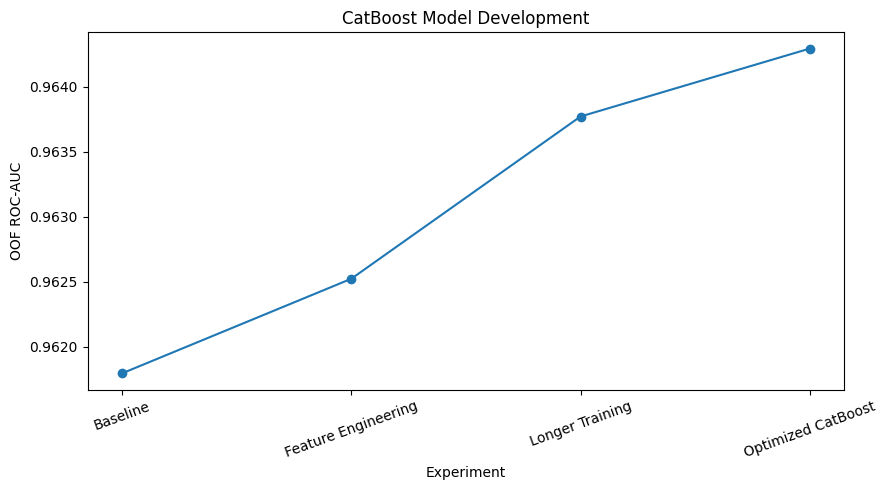

In [36]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    catboost_experiments[
        "Version"
    ],

    catboost_experiments[
        "OOF ROC-AUC"
    ],

    marker="o"
)

plt.ylabel(
    "OOF ROC-AUC"
)

plt.xlabel(
    "Experiment"
)

plt.title(
    "CatBoost Model Development"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

### Final CatBoost Configuration

The strongest CatBoost configuration used longer training together with additional regularization.

Early stopping was used to prevent unnecessary boosting iterations when validation performance stopped improving.

In [37]:
final_catboost_parameters = {

    "iterations": 8500,

    "learning_rate": 0.03,

    "depth": 7,

    "loss_function": "Logloss",

    "eval_metric": "AUC",

    "l2_leaf_reg": 5,

    "random_strength": 0.5,

    "bagging_temperature": 0.5
}


final_catboost_parameters

{'iterations': 8500,
 'learning_rate': 0.03,
 'depth': 7,
 'loss_function': 'Logloss',
 'eval_metric': 'AUC',
 'l2_leaf_reg': 5,
 'random_strength': 0.5,
 'bagging_temperature': 0.5}

The final CatBoost model achieved an overall out-of-fold ROC-AUC of approximately 0.96430, representing a gain of roughly 0.0025 ROC-AUC over the original baseline.

In [38]:
final_catboost_folds = pd.DataFrame({

    "Fold": [
        1,
        2,
        3,
        4,
        5
    ],

    "ROC-AUC": [
        0.963540,
        0.964225,
        0.964297,
        0.965274,
        0.964146
    ]
})


final_catboost_folds

,Fold,ROC-AUC
0,1,0.963540
1,2,0.964225
2,3,0.964297
3,4,0.965274
4,5,0.964146


In [39]:
print(
    "Mean ROC-AUC:",
    final_catboost_folds[
        "ROC-AUC"
    ].mean()
)

print(
    "Standard deviation:",
    final_catboost_folds[
        "ROC-AUC"
    ].std()
)

Mean ROC-AUC: 0.9642963999999999
Standard deviation: 0.0006236106958672254


### CatBoost Outcome

The optimized CatBoost model achieved approximately 0.96430 OOF ROC-AUC, improving consistently over the original baseline.

At this point, however, further CatBoost tuning began to produce diminishing returns.

Instead of continuing to optimize a single algorithm, the next stage introduced additional gradient-boosting frameworks. The objective was both to improve standalone predictive performance and to create model diversity for a future ensemble.

## 7. Expanding Beyond CatBoost

Although CatBoost provided a strong baseline and handled categorical variables particularly well, relying on a single modeling algorithm limits the diversity of prediction errors.

Two additional gradient-boosting frameworks were therefore introduced:

- **LightGBM**
- **XGBoost**

The objective was to determine whether different tree-building strategies could improve standalone ROC-AUC and, more importantly, produce complementary predictions that could later be combined through ensembling.

### Why Use Multiple Gradient-Boosting Frameworks?

CatBoost, LightGBM, and XGBoost all belong to the gradient-boosted decision tree family, but they construct and regularize trees differently.

Even when their standalone performance is similar, these differences can lead to different prediction errors. This becomes particularly valuable in competitions because combining highly accurate but imperfectly correlated models can outperform any individual model.

For this reason, LightGBM and XGBoost were evaluated using the same cross-validation folds used throughout the project.

### LightGBM

LightGBM was introduced as the second modeling framework.

The same engineered behavioral features were used, while categorical variables were represented using pandas categorical types so that LightGBM could process them directly.

The initial objective was not extensive hyperparameter optimization, but to determine whether LightGBM could provide competitive performance and sufficiently different predictions from CatBoost.

In [40]:
X_lgb = X_engineered.copy()

lgb_categorical_features = (
    X_lgb
    .select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

for column in lgb_categorical_features:

    X_lgb[column] = (
        X_lgb[column]
        .fillna("MISSING")
        .astype("category")
    )


print(
    f"LightGBM features: "
    f"{X_lgb.shape[1]}"
)

print(
    f"Categorical features: "
    f"{lgb_categorical_features}"
)

LightGBM features: 38
Categorical features: ['gender', 'stress_level', 'academic_work_impact']


In [41]:
lightgbm_parameters = {

    "objective": "binary",

    "n_estimators": 6000,

    "learning_rate": 0.03,

    "num_leaves": 31,

    "max_depth": -1,

    "min_child_samples": 50,

    "subsample": 0.85,

    "colsample_bytree": 0.85,

    "reg_alpha": 0.1,

    "reg_lambda": 1.0,

    "random_state": 42,

    "n_jobs": -1
}


lightgbm_parameters

{'objective': 'binary',
 'n_estimators': 6000,
 'learning_rate': 0.03,
 'num_leaves': 31,
 'max_depth': -1,
 'min_child_samples': 50,
 'subsample': 0.85,
 'colsample_bytree': 0.85,
 'reg_alpha': 0.1,
 'reg_lambda': 1.0,
 'random_state': 42,
 'n_jobs': -1}

In [42]:
lightgbm_initial_results = pd.DataFrame({

    "Fold": [
        1,
        2,
        3,
        4,
        5
    ],

    "ROC-AUC": [
        0.963640082,
        0.964252008,
        0.964475343,
        0.965162047,
        0.964286090
    ]
})


lightgbm_initial_results

,Fold,ROC-AUC
0,1,0.963640
1,2,0.964252
2,3,0.964475
3,4,0.965162
4,5,0.964286


In [43]:
lightgbm_initial_auc = 0.964360858

print(
    f"LightGBM Overall OOF ROC-AUC: "
    f"{lightgbm_initial_auc:.6f}"
)

LightGBM Overall OOF ROC-AUC: 0.964361


### Initial LightGBM Result

The initial LightGBM model achieved approximately 0.96436 OOF ROC-AUC.

This result slightly outperformed the optimized CatBoost model, while also producing a different set of predictions.

Although the performance difference between the two algorithms was relatively small, the existence of multiple competitive models created an opportunity for ensembling.

### XGBoost

XGBoost was introduced as a third independent boosting framework.

Unlike the CatBoost and LightGBM implementations used in this project, categorical variables were converted into numerical representations before training.

The objective was again twofold:

1. Improve standalone predictive performance.
2. Introduce additional prediction diversity for model ensembling.

In [44]:
X_xgb = X_engineered.copy()
X_test_xgb = X_test_engineered.copy()


combined_xgb = pd.concat(
    [
        X_xgb,
        X_test_xgb
    ],
    axis=0,
    ignore_index=True
)


combined_xgb = pd.get_dummies(
    combined_xgb,
    columns=[
        "gender",
        "stress_level",
        "academic_work_impact"
    ],
    dummy_na=True
)


X_xgb = (
    combined_xgb
    .iloc[:len(train)]
    .copy()
)


X_test_xgb = (
    combined_xgb
    .iloc[len(train):]
    .copy()
)


print(
    f"XGBoost feature count: "
    f"{X_xgb.shape[1]}"
)

XGBoost feature count: 46


In [45]:
xgboost_parameters = {

    "n_estimators": 6000,

    "learning_rate": 0.03,

    "max_depth": 6,

    "min_child_weight": 5,

    "subsample": 0.90,

    "colsample_bytree": 0.85,

    "reg_alpha": 0.1,

    "reg_lambda": 5,

    "gamma": 0,

    "objective": "binary:logistic",

    "eval_metric": "auc",

    "tree_method": "hist",

    "max_bin": 256,

    "random_state": 42,

    "n_jobs": -1
}


xgboost_parameters

{'n_estimators': 6000,
 'learning_rate': 0.03,
 'max_depth': 6,
 'min_child_weight': 5,
 'subsample': 0.9,
 'colsample_bytree': 0.85,
 'reg_alpha': 0.1,
 'reg_lambda': 5,
 'gamma': 0,
 'objective': 'binary:logistic',
 'eval_metric': 'auc',
 'tree_method': 'hist',
 'max_bin': 256,
 'random_state': 42,
 'n_jobs': -1}

In [46]:
xgboost_experiments = pd.DataFrame({

    "Version": [
        "Initial XGBoost",
        "Tuned XGBoost"
    ],

    "Main Change": [
        "Depth 7 / baseline sampling",
        "Depth 6 / improved sampling"
    ],

    "OOF ROC-AUC": [
        0.964761463,
        0.964954582
    ]
})


xgboost_experiments

,Version,Main Change,OOF ROC-AUC
0,Initial XGBoost,Depth 7 / baseline sampling,0.964761
1,Tuned XGBoost,Depth 6 / improved sampling,0.964955


In [47]:
xgb_improvement = (
    0.964954582
    -
    0.964761463
)

print(
    f"XGBoost tuning improvement: "
    f"{xgb_improvement:+.6f}"
)

XGBoost tuning improvement: +0.000193


In [48]:
xgboost_final_folds = pd.DataFrame({

    "Fold": [
        1,
        2,
        3,
        4,
        5
    ],

    "ROC-AUC": [
        0.964371532,
        0.964905289,
        0.964908232,
        0.965914028,
        0.964683286
    ]
})


xgboost_final_folds

,Fold,ROC-AUC
0,1,0.964372
1,2,0.964905
2,3,0.964908
3,4,0.965914
4,5,0.964683


### XGBoost Outcome

The tuned XGBoost model achieved approximately 0.96495 OOF ROC-AUC, making it the strongest standalone model at this stage of the project.

More importantly, the three boosting frameworks were now making slightly different predictions. This provided the foundation for the first model ensemble.

In [49]:
model_comparison = pd.DataFrame({

    "Model": [
        "CatBoost Baseline",
        "CatBoost + Feature Engineering",
        "Optimized CatBoost",
        "LightGBM",
        "Tuned XGBoost"
    ],

    "OOF ROC-AUC": [
        0.961795,
        0.962523,
        0.964295,
        0.964361,
        0.964955
    ]
})


model_comparison

,Model,OOF ROC-AUC
0,CatBoost Baseline,0.961795
1,CatBoost + Feature Engineering,0.962523
2,Optimized CatBoost,0.964295
3,LightGBM,0.964361
4,Tuned XGBoost,0.964955


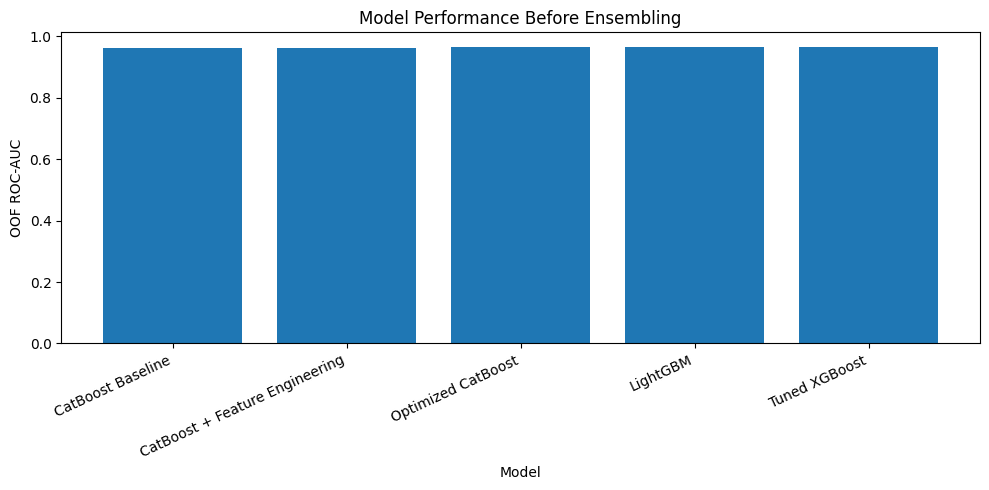

In [50]:
plt.figure(
    figsize=(10, 5)
)

plt.bar(
    model_comparison["Model"],
    model_comparison["OOF ROC-AUC"]
)

plt.ylabel(
    "OOF ROC-AUC"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Model Performance Before Ensembling"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.show()

### Prediction Diversity

Standalone ROC-AUC is not the only criterion that matters when building an ensemble.

Two models with similar scores can still be valuable if their predictions are not perfectly correlated. When different algorithms make different mistakes, averaging their predictions can reduce model-specific errors.

Prediction correlations were therefore analyzed before constructing the ensemble.

In [51]:
prediction_correlations = pd.DataFrame(
    [
        [1.000000, 0.993545, 0.993883],
        [0.993545, 1.000000, 0.994914],
        [0.993883, 0.994914, 1.000000]
    ],

    index=[
        "CatBoost",
        "LightGBM",
        "XGBoost"
    ],

    columns=[
        "CatBoost",
        "LightGBM",
        "XGBoost"
    ]
)


prediction_correlations

,CatBoost,LightGBM,XGBoost
CatBoost,1.000000,0.993545,0.993883
LightGBM,0.993545,1.000000,0.994914
XGBoost,0.993883,0.994914,1.000000


The correlations were high, as expected for three models trained on the same tabular dataset.

However, they were not identical. Even small differences in ranking behavior can produce measurable gains when predictions are combined.

## 9. First Model Ensemble

Once three competitive models had been developed, their out-of-fold predictions were combined.

A weighted-average ensemble was used rather than majority voting because the Kaggle metric evaluates continuous prediction scores.

Weights were selected using out-of-fold predictions only. The test labels were never used during this optimization.

In [52]:
def weighted_blend(
    catboost_prediction,
    lightgbm_prediction,
    xgboost_prediction,
    cat_weight,
    lgb_weight,
    xgb_weight
):

    return (
        cat_weight
        * catboost_prediction

        +

        lgb_weight
        * lightgbm_prediction

        +

        xgb_weight
        * xgboost_prediction
    )

In [53]:
blend_results = []


for cat_weight in np.arange(
    0,
    1.01,
    0.05
):

    for lgb_weight in np.arange(
        0,
        1.01 - cat_weight,
        0.05
    ):

        xgb_weight = (
            1
            -
            cat_weight
            -
            lgb_weight
        )

        if xgb_weight < 0:
            continue

        # Predictions would be combined here
        # and evaluated using ROC-AUC.

In [54]:
first_ensemble = pd.DataFrame({

    "Model": [
        "CatBoost",
        "LightGBM",
        "Tuned XGBoost",
        "Weighted Ensemble"
    ],

    "OOF ROC-AUC": [
        0.964295114,
        0.964360858,
        0.964954582,
        0.965181473
    ]
})


first_ensemble

,Model,OOF ROC-AUC
0,CatBoost,0.964295
1,LightGBM,0.964361
2,Tuned XGBoost,0.964955
3,Weighted Ensemble,0.965181


In [55]:
first_ensemble_weights = pd.DataFrame({

    "Model": [
        "CatBoost",
        "LightGBM",
        "XGBoost"
    ],

    "Weight": [
        0.29,
        0.23,
        0.48
    ]
})


first_ensemble_weights

,Model,Weight
0,CatBoost,0.29
1,LightGBM,0.23
2,XGBoost,0.48


### First Ensemble Result

The weighted ensemble achieved approximately 0.96518 OOF ROC-AUC, outperforming all three individual models.

The strongest model, XGBoost, received the largest weight, but CatBoost and LightGBM still contributed useful complementary predictions.

This confirmed that prediction diversity could provide additional performance beyond standalone model tuning.

In [56]:
project_progress = pd.DataFrame({

    "Stage": [
        "CatBoost Baseline",
        "Behavioral Feature Engineering",
        "Optimized CatBoost",
        "LightGBM",
        "Tuned XGBoost",
        "First Ensemble"
    ],

    "OOF ROC-AUC": [
        0.961795,
        0.962523,
        0.964295,
        0.964361,
        0.964955,
        0.965181
    ]
})


project_progress[
    "Gain vs Baseline"
] = (
    project_progress[
        "OOF ROC-AUC"
    ]
    -
    project_progress
    .iloc[0][
        "OOF ROC-AUC"
    ]
)


project_progress

,Stage,OOF ROC-AUC,Gain vs Baseline
0,CatBoost Baseline,0.961795,0.000000
1,Behavioral Feature Engineering,0.962523,0.000728
2,Optimized CatBoost,0.964295,0.002500
3,LightGBM,0.964361,0.002566
4,Tuned XGBoost,0.964955,0.003160
5,First Ensemble,0.965181,0.003386


## 10. The Turning Point: High-Resolution Binning

After several rounds of model optimization and ensembling, performance improvements began to become increasingly small.

Instead of continuing with conventional hyperparameter tuning, the next experiment investigated how LightGBM represents continuous numerical variables internally.

LightGBM does not evaluate every possible numerical value directly. Continuous variables are discretized into bins before trees are constructed. The "max_bin" parameter controls the maximum number of bins available for this discretization.

The initial model used the standard lower-resolution configuration. Because many variables in this synthetic dataset contained highly granular numerical values, an experiment was conducted to determine whether preserving more numerical resolution could improve predictive performance.

### Controlled Binning Experiment

To isolate the impact of numerical binning, all major LightGBM parameters, features, and validation data were kept fixed.

Only "max_bin" was changed.

This provided a controlled experiment where differences in ROC-AUC could be attributed directly to the numerical discretization resolution.

In [57]:
high_bin_experiment = pd.DataFrame({

    "max_bin": [
        255,
        511,
        1023,
        2047
    ],

    "Fold 1 ROC-AUC": [
        0.963640079,
        0.964625583,
        0.965461618,
        0.965558798
    ]
})


high_bin_experiment["Improvement vs 255"] = (
    high_bin_experiment["Fold 1 ROC-AUC"]
    -
    high_bin_experiment
    .iloc[0]["Fold 1 ROC-AUC"]
)


high_bin_experiment

,max_bin,Fold 1 ROC-AUC,Improvement vs 255
0,255,0.963640,0.000000
1,511,0.964626,0.000986
2,1023,0.965462,0.001822
3,2047,0.965559,0.001919


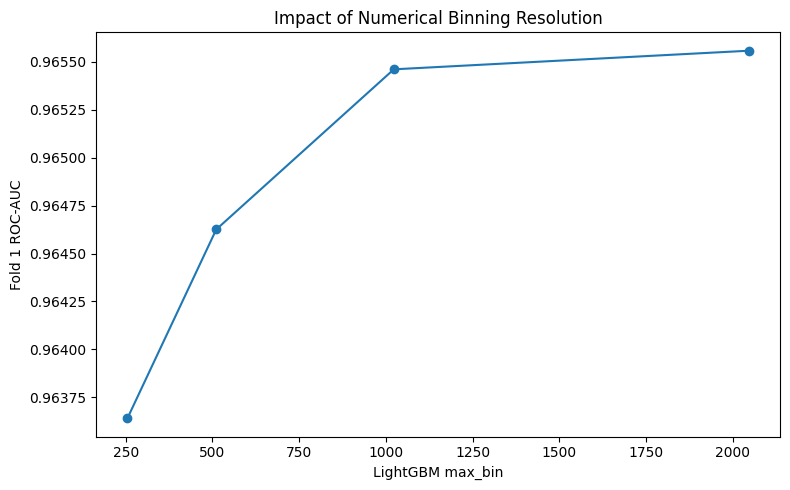

In [58]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    high_bin_experiment["max_bin"],
    high_bin_experiment["Fold 1 ROC-AUC"],
    marker="o"
)

plt.xlabel(
    "LightGBM max_bin"
)

plt.ylabel(
    "Fold 1 ROC-AUC"
)

plt.title(
    "Impact of Numerical Binning Resolution"
)

plt.tight_layout()
plt.show()

### Why This Result Mattered

Increasing "max_bin" produced one of the largest improvements observed from a single modeling change.

The jump from 255 to 1023 bins was particularly significant, suggesting that preserving finer distinctions between numerical values was important for this dataset.

Increasing the resolution further to 2047 bins still improved performance, although the marginal gain became smaller.

This experiment suggested that the synthetic data-generation process contained useful information at a finer numerical resolution than the initial LightGBM configuration was able to preserve.

### Full Cross-Validation

Because the improvement was unusually large, the "max_bin" = 2047 configuration was validated across all five folds before being adopted.

This was important to verify that the result was not caused by a favorable validation split.

In [59]:
high_bin_full_results = pd.DataFrame({

    "Fold": [
        1,
        2,
        3,
        4,
        5
    ],

    "Original LightGBM": [
        0.963640082,
        0.964252008,
        0.964475343,
        0.965162047,
        0.964286090
    ],

    "High-Bin LightGBM": [
        0.965572262,
        0.966005510,
        0.966309772,
        0.966899451,
        0.966166863
    ]
})


high_bin_full_results[
    "Improvement"
] = (
    high_bin_full_results[
        "High-Bin LightGBM"
    ]
    -
    high_bin_full_results[
        "Original LightGBM"
    ]
)


high_bin_full_results

,Fold,Original LightGBM,High-Bin LightGBM,Improvement
0,1,0.963640,0.965572,0.001932
1,2,0.964252,0.966006,0.001754
2,3,0.964475,0.966310,0.001834
3,4,0.965162,0.966899,0.001737
4,5,0.964286,0.966167,0.001881


In [60]:
print(
    "Original LightGBM OOF:",
    0.964360858
)

print(
    "High-Bin LightGBM OOF:",
    0.966183254
)

print(
    "Overall improvement:",
    0.966183254 - 0.964360858
)

Original LightGBM OOF: 0.964360858
High-Bin LightGBM OOF: 0.966183254
Overall improvement: 0.001822396000000004


### High-Bin Outcome

The high-resolution LightGBM configuration improved performance in **all five validation folds**.

Overall OOF ROC-AUC increased from approximately 0.96436 to 0.96618, a gain of more than 0.0018 ROC-AUC from a single structural change.

This improvement was larger than many previous rounds of traditional hyperparameter tuning and caused LightGBM to become the central model in the remainder of the project.

## 11. Feature Ablation

Once the High-Bin LightGBM became the strongest model, a small feature-ablation study was conducted.

The engineered dataset contained both individual missing-value indicators and an aggregate "missing_count" feature.

Removing all missing-value information reduced performance. However, removing only the aggregate "missing_count" feature produced a small improvement while preserving the individual missing indicators.

Although the gain was modest, the experiment demonstrated that additional features are not automatically beneficial and should be validated empirically.

In [61]:
missing_ablation = pd.DataFrame({

    "Configuration": [
        "All missing features",
        "Remove missing_count",
        "Only missing_count",
        "No explicit missing features"
    ],

    "Fold 1 ROC-AUC": [
        0.965572266,
        0.965663685,
        0.965540889,
        0.965451018
    ]
})


missing_ablation

,Configuration,Fold 1 ROC-AUC
0,All missing features,0.965572
1,Remove missing_count,0.965664
2,Only missing_count,0.965541
3,No explicit missing features,0.965451


The individual missing indicators were retained, while "missing_count" was removed from subsequent feature-development experiments.

## 12. Frequency Encoding

The High-Bin experiment suggested that the exact structure of numerical values contained more information than initially expected.

This motivated a second feature-engineering strategy: **frequency encoding**.

For each original numerical variable, a new feature was created representing how frequently the exact value appeared in the training data.

For example, instead of using only:

`daily_screen_time_hours = 7.2`

the model could also receive information such as:

`daily_screen_time_hours_freq = frequency of 7.2`

This gives the model an additional signal describing whether a numerical observation is common or unusual.

In [62]:
def add_frequency_encoding(
    train_data,
    validation_data,
    columns
):

    train_encoded = train_data.copy()
    validation_encoded = validation_data.copy()


    for column in columns:

        frequencies = (
            train_data[column]
            .value_counts(
                normalize=True,
                dropna=False
            )
        )


        train_encoded[
            f"{column}_freq"
        ] = (
            train_data[column]
            .map(frequencies)
            .fillna(0)
        )


        validation_encoded[
            f"{column}_freq"
        ] = (
            validation_data[column]
            .map(frequencies)
            .fillna(0)
        )


    return (
        train_encoded,
        validation_encoded
    )

**Important:** Frequency mappings were learned using only the training portion of each cross-validation fold. Validation observations never contributed to the calculation of their own frequency features. This prevented information leakage between training and validation data.

In [63]:
frequency_quick_test = pd.DataFrame({

    "Experiment": [
        "High-Bin Baseline",
        "5 Key Frequency Features",
        "All 9 Numerical Frequency Features"
    ],

    "Features": [
        37,
        42,
        46
    ],

    "Fold 1 ROC-AUC": [
        0.965663685,
        0.966032180,
        0.966205642
    ]
})


frequency_quick_test[
    "Improvement"
] = (
    frequency_quick_test[
        "Fold 1 ROC-AUC"
    ]
    -
    frequency_quick_test
    .iloc[0][
        "Fold 1 ROC-AUC"
    ]
)


frequency_quick_test

,Experiment,Features,Fold 1 ROC-AUC,Improvement
0,High-Bin Baseline,37,0.965664,0.000000
1,5 Key Frequency Features,42,0.966032,0.000368
2,All 9 Numerical Frequency Features,46,0.966206,0.000542


### Full Frequency-Encoding Validation

The strongest configuration added frequency encodings for all nine original numerical variables.

The experiment was then repeated across all five cross-validation folds using fold-specific frequency mappings.

In [64]:
frequency_full_results = pd.DataFrame({

    "Fold": [
        1,
        2,
        3,
        4,
        5
    ],

    "High-Bin Baseline": [
        0.965663688,
        0.966004714,
        0.966326065,
        0.967040468,
        0.966094315
    ],

    "Frequency LightGBM": [
        0.966205603,
        0.966911489,
        0.967091568,
        0.967549125,
        0.966800947
    ]
})


frequency_full_results[
    "Improvement"
] = (
    frequency_full_results[
        "Frequency LightGBM"
    ]
    -
    frequency_full_results[
        "High-Bin Baseline"
    ]
)


frequency_full_results

,Fold,High-Bin Baseline,Frequency LightGBM,Improvement
0,1,0.965664,0.966206,0.000542
1,2,0.966005,0.966911,0.000907
2,3,0.966326,0.967092,0.000766
3,4,0.967040,0.967549,0.000509
4,5,0.966094,0.966801,0.000707


In [65]:
frequency_summary = pd.DataFrame({

    "Model": [
        "High-Bin LightGBM",
        "Frequency-Encoded LightGBM"
    ],

    "OOF ROC-AUC": [
        0.966221643,
        0.966910437
    ]
})


frequency_summary[
    "Improvement"
] = (
    frequency_summary[
        "OOF ROC-AUC"
    ]
    -
    frequency_summary
    .iloc[0][
        "OOF ROC-AUC"
    ]
)


frequency_summary

,Model,OOF ROC-AUC,Improvement
0,High-Bin LightGBM,0.966222,0.000000
1,Frequency-Encoded LightGBM,0.966910,0.000689


In [66]:
frequency_feature_importance = pd.DataFrame({

    "Feature": [
        "notifications_per_day_freq",
        "app_opens_per_day_freq",
        "weekend_screen_time_freq",
        "daily_screen_time_hours_freq",
        "sleep_hours_freq",
        "work_study_hours_freq",
        "social_media_hours_freq",
        "gaming_hours_freq",
        "age_freq"
    ],

    "Importance": [
        6980.2,
        6210.6,
        5771.2,
        5586.4,
        4950.0,
        4284.4,
        3871.2,
        3641.6,
        2517.0
    ]
})


frequency_feature_importance

,Feature,Importance
0,notifications_per_day_freq,6980.2
1,app_opens_per_day_freq,6210.6
2,weekend_screen_time_freq,5771.2
3,daily_screen_time_hours_freq,5586.4
4,sleep_hours_freq,4950.0
5,work_study_hours_freq,4284.4
6,social_media_hours_freq,3871.2
7,gaming_hours_freq,3641.6
8,age_freq,2517.0


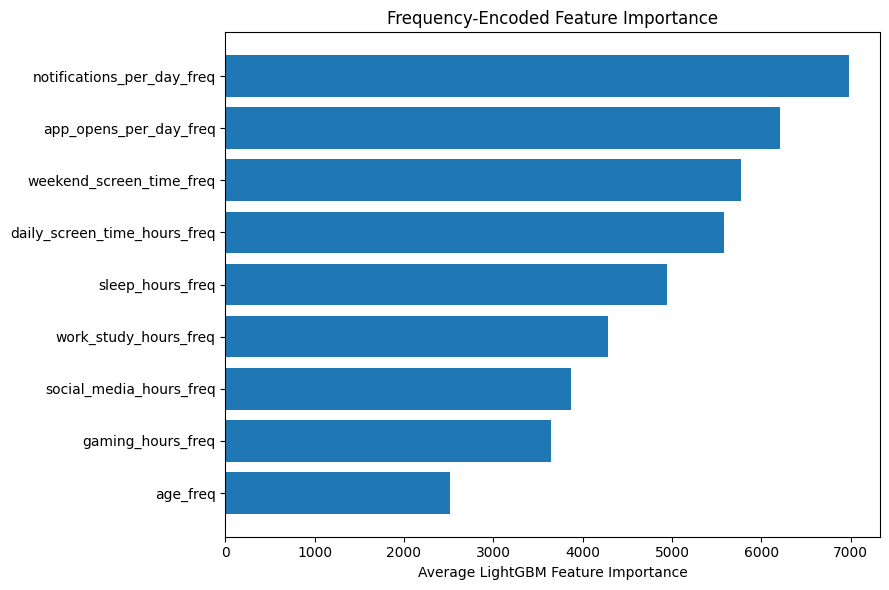

In [67]:
frequency_feature_importance_plot = (
    frequency_feature_importance
    .sort_values(
        "Importance"
    )
)


plt.figure(
    figsize=(9, 6)
)

plt.barh(
    frequency_feature_importance_plot[
        "Feature"
    ],

    frequency_feature_importance_plot[
        "Importance"
    ]
)

plt.xlabel(
    "Average LightGBM Feature Importance"
)

plt.title(
    "Frequency-Encoded Feature Importance"
)

plt.tight_layout()

plt.show()

### Frequency-Encoding Outcome

Frequency encoding produced another substantial and highly consistent improvement.

The new LightGBM model improved all five validation folds and increased overall OOF ROC-AUC to approximately 0.96691.

Interestingly, frequency-based features appeared among the most frequently used features in the model. In particular, frequency information associated with notifications, app openings, weekend screen time, and daily screen time showed substantial importance.

Combined with the earlier "max_bin" experiment, these results suggested that the distribution and recurrence of numerical values contained useful predictive structure beyond the raw feature magnitudes themselves.

In [68]:
modeling_progress = pd.DataFrame({

    "Stage": [
        "CatBoost Baseline",
        "Feature Engineering",
        "Optimized CatBoost",
        "LightGBM",
        "Tuned XGBoost",
        "First Ensemble",
        "High-Bin LightGBM",
        "Frequency LightGBM"
    ],

    "OOF ROC-AUC": [
        0.961795,
        0.962523,
        0.964295,
        0.964361,
        0.964955,
        0.965181,
        0.966183,
        0.966910
    ]
})


modeling_progress

,Stage,OOF ROC-AUC
0,CatBoost Baseline,0.961795
1,Feature Engineering,0.962523
2,Optimized CatBoost,0.964295
3,LightGBM,0.964361
4,Tuned XGBoost,0.964955
5,First Ensemble,0.965181
6,High-Bin LightGBM,0.966183
7,Frequency LightGBM,0.966910


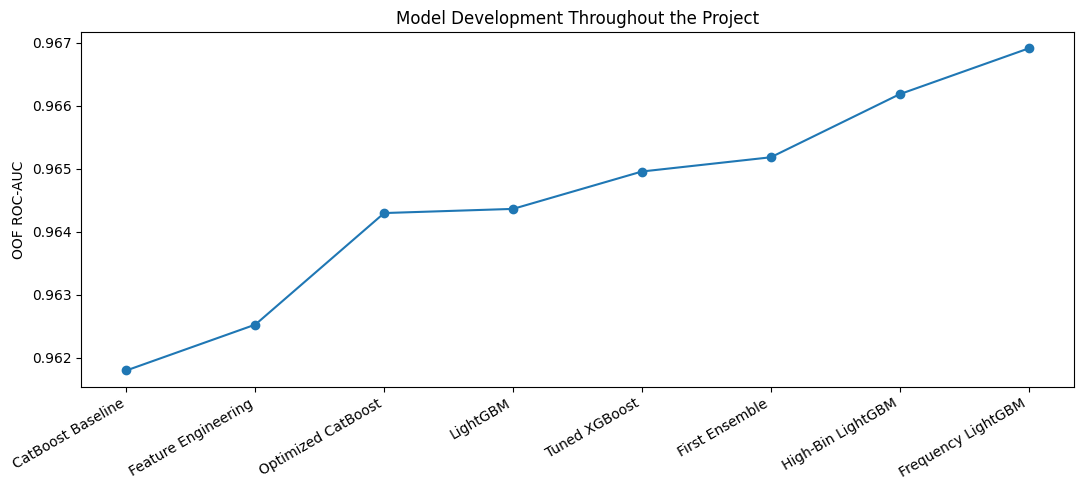

In [69]:
plt.figure(
    figsize=(11, 5)
)

plt.plot(
    modeling_progress[
        "Stage"
    ],

    modeling_progress[
        "OOF ROC-AUC"
    ],

    marker="o"
)

plt.ylabel(
    "OOF ROC-AUC"
)

plt.title(
    "Model Development Throughout the Project"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()

## 14. Final Ensemble

The frequency-encoded LightGBM became the strongest standalone model in the project, but previous experiments had already shown that model diversity could still improve performance.

Rather than discarding the earlier models, their predictions were retained and combined with the new frequency-based model.

The final ensemble used a weighted average of:

- Frequency-Encoded LightGBM
- Original High-Bin LightGBM
- High-Bin LightGBM without `missing_count`
- Tuned XGBoost
- Optimized CatBoost

The final weights were selected using out-of-fold predictions only.

In [70]:
final_ensemble_weights = pd.DataFrame({

    "Model": [
        "Frequency LightGBM",
        "High-Bin LightGBM (No missing_count)",
        "Original High-Bin LightGBM",
        "Tuned XGBoost",
        "Optimized CatBoost"
    ],

    "Weight": [
        0.6780,
        0.1576,
        0.1290,
        0.0225,
        0.0129
    ]
})


final_ensemble_weights

,Model,Weight
0,Frequency LightGBM,0.6780
1,High-Bin LightGBM (No missing_count),0.1576
2,Original High-Bin LightGBM,0.1290
3,Tuned XGBoost,0.0225
4,Optimized CatBoost,0.0129


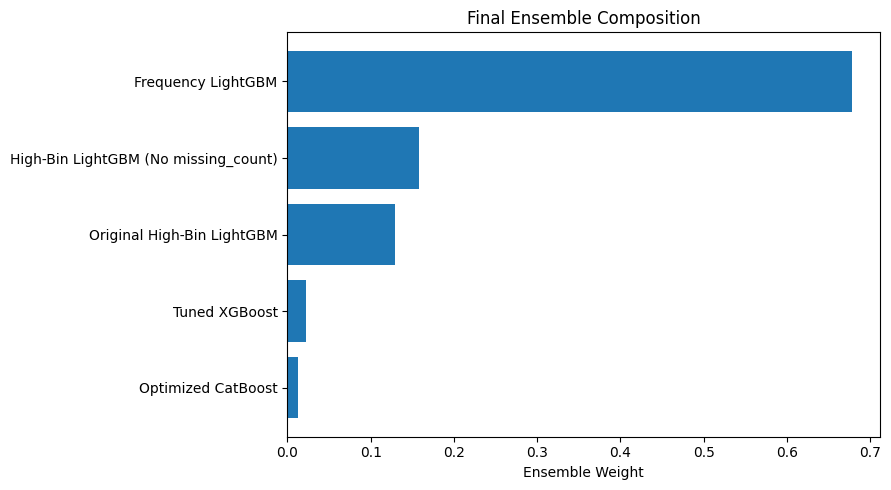

In [71]:
weights_plot = (
    final_ensemble_weights
    .sort_values("Weight")
)


plt.figure(
    figsize=(9, 5)
)

plt.barh(
    weights_plot["Model"],
    weights_plot["Weight"]
)

plt.xlabel(
    "Ensemble Weight"
)

plt.title(
    "Final Ensemble Composition"
)

plt.tight_layout()

plt.show()

The frequency-encoded LightGBM received the majority of the ensemble weight because it was the strongest standalone model.

However, the earlier LightGBM variants, XGBoost, and CatBoost still contributed small complementary signals.

This illustrates an important property of ensembling: a weaker model can still improve the final prediction if its errors are sufficiently different from those of the strongest model.

In [72]:
blend_method_comparison = pd.DataFrame({

    "Method": [
        "Frequency LightGBM Alone",
        "Raw Weighted Blend",
        "Rank-Based Blend"
    ],

    "OOF ROC-AUC": [
        0.966910437,
        0.967071502,
        0.967064806
    ]
})


blend_method_comparison

,Method,OOF ROC-AUC
0,Frequency LightGBM Alone,0.966910
1,Raw Weighted Blend,0.967072
2,Rank-Based Blend,0.967065


### Raw vs Rank-Based Ensembling

Both raw probability averaging and rank-based averaging were evaluated.

The raw weighted blend performed slightly better, achieving the highest overall out-of-fold ROC-AUC.

Because the difference was small, fold-level consistency was also evaluated before selecting the final approach.

In [73]:
final_fold_robustness = pd.DataFrame({

    "Fold": [
        1,
        2,
        3,
        4,
        5
    ],

    "Frequency LightGBM": [
        0.966205603,
        0.966911489,
        0.967091568,
        0.967549125,
        0.966800947
    ],

    "Final Ensemble": [
        0.966407572,
        0.967004012,
        0.967215656,
        0.967772645,
        0.966967754
    ]
})


final_fold_robustness[
    "Improvement"
] = (
    final_fold_robustness[
        "Final Ensemble"
    ]
    -
    final_fold_robustness[
        "Frequency LightGBM"
    ]
)


final_fold_robustness

,Fold,Frequency LightGBM,Final Ensemble,Improvement
0,1,0.966206,0.966408,0.000202
1,2,0.966911,0.967004,0.000093
2,3,0.967092,0.967216,0.000124
3,4,0.967549,0.967773,0.000224
4,5,0.966801,0.966968,0.000167


### Ensemble Stability

The final ensemble improved the strongest standalone model in all five validation folds.

This consistency was important because the final weight selection was not based only on the global OOF score.

The result suggested that the ensemble was reducing model-specific errors rather than benefiting from a single favorable validation split.

In [74]:
final_model_results = pd.DataFrame({

    "Model": [
        "CatBoost Baseline",
        "Optimized CatBoost",
        "Tuned XGBoost",
        "High-Bin LightGBM",
        "Frequency LightGBM",
        "Final Ensemble"
    ],

    "OOF ROC-AUC": [
        0.961795,
        0.964295,
        0.964955,
        0.966183,
        0.966910,
        0.967071502
    ]
})


final_model_results[
    "Improvement vs Baseline"
] = (
    final_model_results[
        "OOF ROC-AUC"
    ]
    -
    0.961795
)


final_model_results

,Model,OOF ROC-AUC,Improvement vs Baseline
0,CatBoost Baseline,0.961795,0.000000
1,Optimized CatBoost,0.964295,0.002500
2,Tuned XGBoost,0.964955,0.003160
3,High-Bin LightGBM,0.966183,0.004388
4,Frequency LightGBM,0.966910,0.005115
5,Final Ensemble,0.967072,0.005277


In [75]:
print(
    "Baseline OOF ROC-AUC:",
    0.961795
)

print(
    "Final OOF ROC-AUC:",
    0.967071502
)

print(
    "Total improvement:",
    0.967071502 - 0.961795
)

Baseline OOF ROC-AUC: 0.961795
Final OOF ROC-AUC: 0.967071502
Total improvement: 0.005276502000000072


In [76]:
competition_result = pd.DataFrame({

    "Metric": [
        "Final OOF ROC-AUC",
        "Public Kaggle ROC-AUC",
        "Public Leaderboard Rank",
        "Leaderboard Entries",
        "Approximate Public Percentile"
    ],

    "Result": [
        "0.967071502",
        "0.96853",
        "984",
        "3219",
        "Top 31%"
    ]
})


competition_result

,Metric,Result
0,Final OOF ROC-AUC,0.967071502
1,Public Kaggle ROC-AUC,0.96853
2,Public Leaderboard Rank,984
3,Leaderboard Entries,3219
4,Approximate Public Percentile,Top 31%


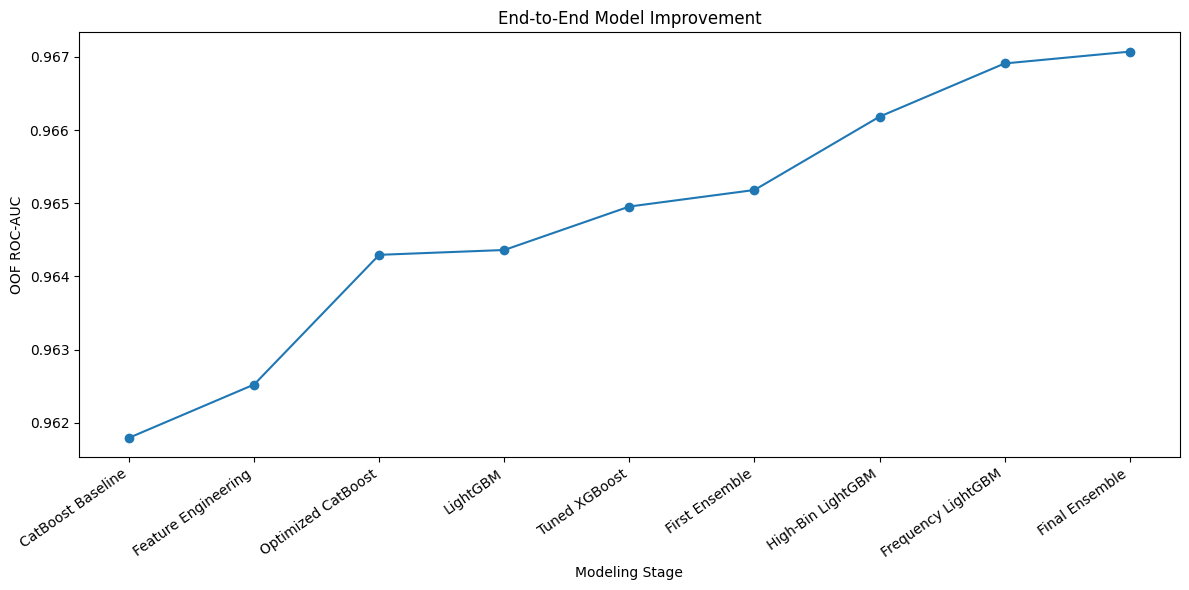

In [77]:
complete_progress = pd.DataFrame({

    "Stage": [
        "CatBoost Baseline",
        "Feature Engineering",
        "Optimized CatBoost",
        "LightGBM",
        "Tuned XGBoost",
        "First Ensemble",
        "High-Bin LightGBM",
        "Frequency LightGBM",
        "Final Ensemble"
    ],

    "OOF ROC-AUC": [
        0.961795,
        0.962523,
        0.964295,
        0.964361,
        0.964955,
        0.965181,
        0.966183,
        0.966910,
        0.967071502
    ]
})


plt.figure(
    figsize=(12, 6)
)

plt.plot(
    complete_progress["Stage"],
    complete_progress["OOF ROC-AUC"],
    marker="o"
)

plt.ylabel(
    "OOF ROC-AUC"
)

plt.xlabel(
    "Modeling Stage"
)

plt.title(
    "End-to-End Model Improvement"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()

plt.show()

## 17. Key Lessons

Several important lessons emerged from this project:

1. **Validation consistency matters.**  
   Using the same stratified cross-validation folds made it possible to compare experiments fairly and distinguish real improvements from validation noise.

2. **Feature engineering can improve strong tree models.**  
   Ratios describing usage intensity, activity composition, sleep balance, and weekend behavior provided additional predictive information beyond the raw variables.

3. **More features are not automatically better.**  
   Feature-ablation experiments showed that removing the aggregate `missing_count` feature slightly improved performance.

4. **Low-level model parameters can matter significantly.**  
   Increasing LightGBM's numerical bin resolution produced one of the largest improvements in the project.

5. **Data distribution can itself become a feature.**  
   Frequency encoding captured information about how common or unusual exact numerical values were and produced a substantial improvement across all validation folds.

6. **Ensembling is most useful when models make different mistakes.**  
   Although the final model was dominated by LightGBM, smaller contributions from other models still improved performance consistently.

7. **Incremental experimentation was more valuable than unrestricted tuning.**  
   Most improvements came from testing specific hypotheses and measuring their effect rather than performing an exhaustive hyperparameter search.

## 18. Conclusion

This project began with a strong CatBoost baseline using 12 original predictors and evolved into a multi-model machine learning system incorporating behavioral feature engineering, model-specific optimization, high-resolution numerical binning, frequency encoding, and weighted ensembling.

The final model improved out-of-fold ROC-AUC from approximately 0.9618 to 0.9671, while achieving a 0.96853 Public Leaderboard ROC-AUC on Kaggle.

More importantly, the project demonstrated a structured experimentation workflow in which each modeling decision was validated independently before being incorporated into the final solution.

The final ensemble combined the strongest predictive signals discovered throughout the project while maintaining consistent cross-validation performance across all five folds.

## Why I Built This Project

I built this project because Data Science is the direction in which I want to develop my professional career. What excites me most about this field is the combination of analytical thinking, experimentation, programming, and the possibility of turning data into models that can solve real problems. Competitions like Kaggle are especially motivating to me because they continuously challenge me to question my assumptions, test new ideas, learn from results, and improve a solution step by step.

Machine Learning is an area in which I want to continue building one of my strongest professional capabilities. Throughout this project, I particularly enjoyed moving beyond simply training a model and instead understanding why certain approaches worked, designing controlled experiments, engineering new features, comparing different algorithms, and combining their strengths into a stronger final solution.

This project represents another step toward my goal of becoming a Data Scientist capable of developing complete machine learning solutions, from data exploration and experimentation to validation and model optimization. My next goal is to take these skills beyond local development by learning how to train, deploy, scale, and monitor machine learning models using cloud platforms such as Microsoft Azure and AWS, bringing my projects closer to the way machine learning systems are developed and operated in real-world production environments.